# Part A - Dataset Exploration

## Shopee Product Matching - Dataset Exploration
## Importing Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import collections

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10
plt.rcParams["figure.titlesize"] = 14

DATA_DIR = "../input/shopee-product-matching" if os.path.exists("../input/shopee-product-matching") else "."
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "train_images")

## Dataset Loading

In [1]:
df = pd.read_csv(TRAIN_CSV)

print("=== DATASET OVERVIEW ===")
print(f"Total rows (listings): {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}\n")

df.head()

=== DATASET OVERVIEW ===
Total rows (listings): 34250
Columns: ['posting_id', 'image', 'image_phash', 'title', 'label_group']
Missing values:
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64



,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


## Statistical Distribution Analysis

=== UNIQUE ENTITY COUNTS ===
Total Product Listings: 34250
Unique Product Groups (label_group): 11014
Unique Images: 32412 (Duplicates: 1838)
Unique Image pHashes: 28735 (Duplicates: 5515)
Unique Titles: 33117 (Duplicates: 1133)

=== LABEL GROUP SIZE METRICS ===
Min listings per group: 2
Max listings per group: 51
Mean listings per group: 3.11
Median listings per group: 2.00


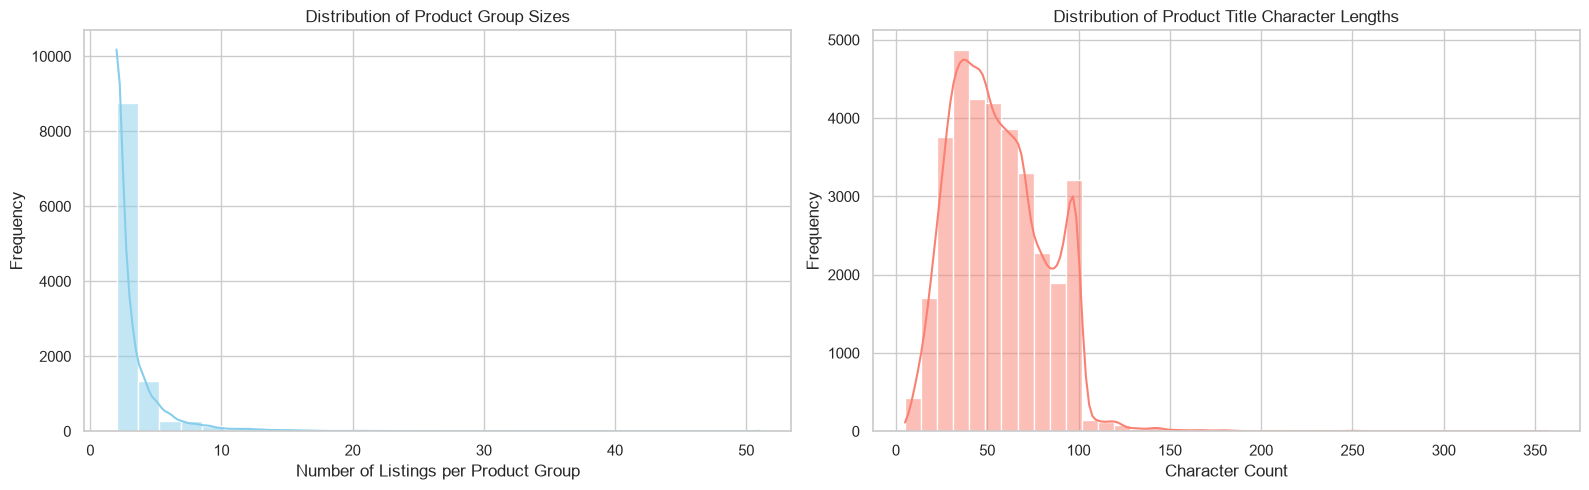

In [2]:
# Unique Counts
n_listings = len(df)
n_groups = df["label_group"].nunique()
n_images = df["image"].nunique()
n_phashes = df["image_phash"].nunique()
n_titles = df["title"].nunique()

print("=== UNIQUE ENTITY COUNTS ===")
print(f"Total Product Listings: {n_listings}")
print(f"Unique Product Groups (label_group): {n_groups}")
print(f"Unique Images: {n_images} (Duplicates: {n_listings - n_images})")
print(f"Unique Image pHashes: {n_phashes} (Duplicates: {n_listings - n_phashes})")
print(f"Unique Titles: {n_titles} (Duplicates: {n_listings - n_titles})")

# Group Size Statistics
group_sizes = df.groupby("label_group").size()

print("\n=== LABEL GROUP SIZE METRICS ===")
print(f"Min listings per group: {group_sizes.min()}")
print(f"Max listings per group: {group_sizes.max()}")
print(f"Mean listings per group: {group_sizes.mean():.2f}")
print(f"Median listings per group: {group_sizes.median():.2f}")

# Plotting Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Group Size Distribution
sns.histplot(group_sizes, bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Product Group Sizes")
axes[0].set_xlabel("Number of Listings per Product Group")
axes[0].set_ylabel("Frequency")

# Plot 2: Title Length Distribution
title_lengths = df["title"].apply(len)
sns.histplot(title_lengths, bins=40, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Product Title Character Lengths")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Similarities and Noises

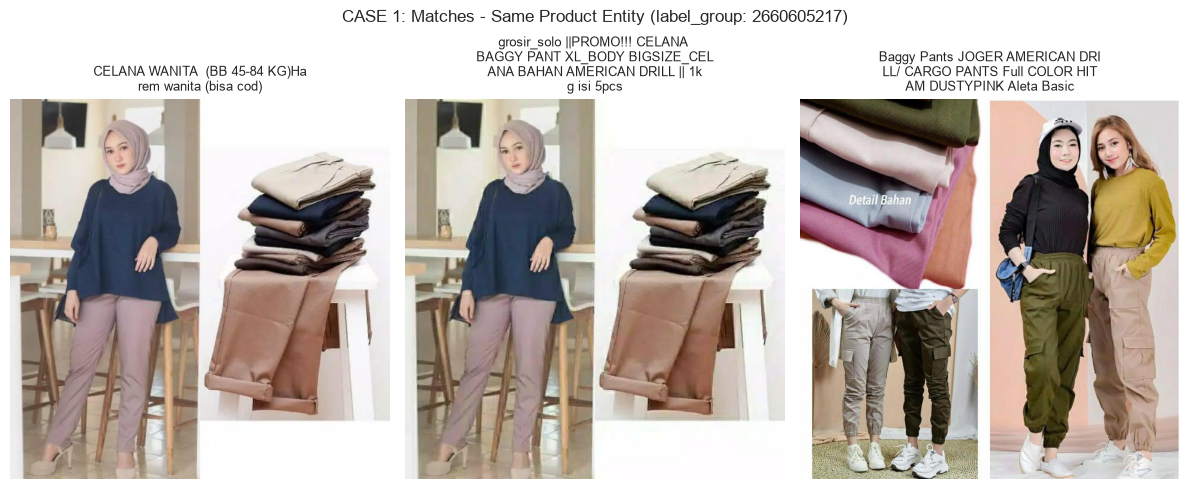

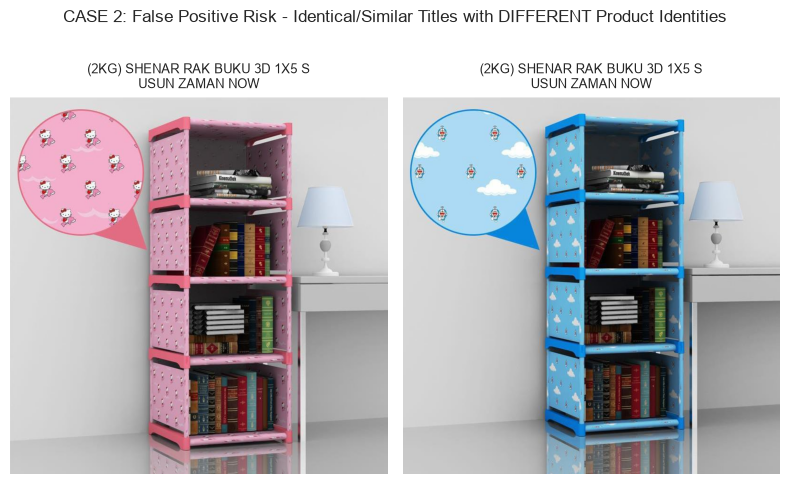

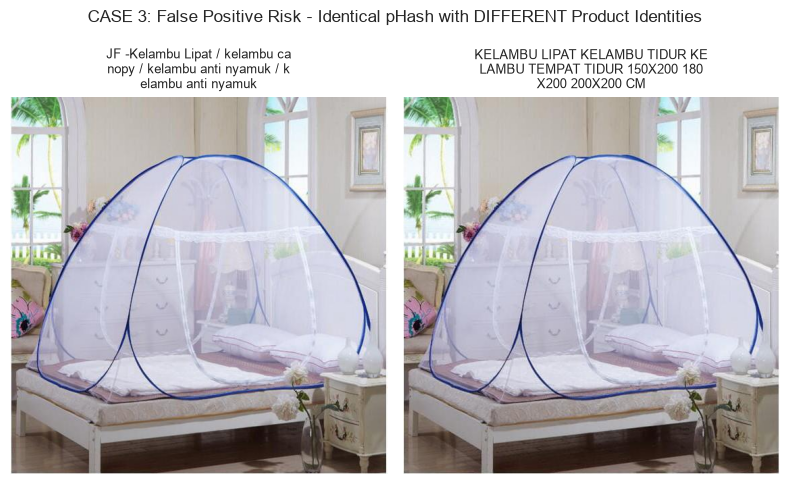

In [3]:
def display_image_grid(image_paths, titles, main_title="Product Comparison"):
    """Utility function to display a horizontal grid of product images and titles."""
    n = len(image_paths)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, img_path, title in zip(axes, image_paths, titles):
        full_path = os.path.join(IMAGE_DIR, img_path)
        if os.path.exists(full_path):
            img = Image.open(full_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Image Not Found", ha="center", va="center")
        ax.set_title("\n".join([title[i:i+30] for i in range(0, len(title), 30)]), fontsize=9)
        ax.axis("off")
    
    plt.suptitle(main_title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# --- CASE 1: Same Product Identity (Same label_group), Visually Different Images ---
same_group_sample = df.groupby("label_group").filter(lambda x: len(x) >= 3)
sample_group_id = same_group_sample["label_group"].iloc[0]
group_items = df[df["label_group"] == sample_group_id].head(3)

display_image_grid(
    group_items["image"].tolist(), 
    group_items["title"].tolist(), 
    main_title=f"CASE 1: Matches - Same Product Entity (label_group: {sample_group_id})"
)

# --- CASE 2: Near-Identical Titles, Different Product Identities (Different label_group) ---
# Finding titles with high overlap but different labels
title_counts = df.groupby("title")["label_group"].nunique()
diff_label_same_title = title_counts[title_counts > 1].index

if len(diff_label_same_title) > 0:
    sample_title = diff_label_same_title[0]
    conflict_items = df[df["title"] == sample_title].head(3)
    display_image_grid(
        conflict_items["image"].tolist(), 
        conflict_items["title"].tolist(), 
        main_title="CASE 2: False Positive Risk - Identical/Similar Titles with DIFFERENT Product Identities"
    )

# --- CASE 3: Identical Image pHash, Different Product Identities ---
phash_counts = df.groupby("image_phash")["label_group"].nunique()
diff_label_same_phash = phash_counts[phash_counts > 1].index

if len(diff_label_same_phash) > 0:
    sample_phash = diff_label_same_phash[0]
    phash_items = df[df["image_phash"] == sample_phash].head(3)
    display_image_grid(
        phash_items["image"].tolist(), 
        phash_items["title"].tolist(), 
        main_title="CASE 3: False Positive Risk - Identical pHash with DIFFERENT Product Identities"
    )